# 1 - Imports

In [6]:
%reload_ext autoreload
%autoreload 2

In [7]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))

In [8]:
from src.utils import templates, config, io

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/pypdf/_crypt_providers/_cryptography.py:32: CryptographyDeprecationWarning: ARC4 has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.ARC4 and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  from cryptography.hazmat.primitives.ciphers.algorithms import AES, ARC4


# 2 - Intigration

## 2.1 - Loading Datasets

In [9]:
oecd_rating_matrix = io.load_csv(config.INTERIM_DATA_DIR / 'oecd_rating_matrix.csv', index_col=0)
oecd_rating_matrix

,1999-01-01,2000-01-01,2001-01-01,2002-01-01,2003-01-01,2004-01-01,2005-01-01,2006-01-01,2007-01-01,2008-01-01,...,2017-01-01,2018-01-01,2019-01-01,2020-01-01,2021-01-01,2022-01-01,2023-01-01,2024-01-01,2025-01-01,2026-01-01
ISO3_COUNTRY_CODE,,,,,,,,,,,,,,,,,,,,,
AFG,7,7,-,-,-,-,-,-,-,7,...,7,7,7,7,7,7,7,7,7,7
ALB,7,7,7,7,7,7,6,6,6,6,...,6,6,6,5,5,5,5,5,5,4
DZA,6,6,5,5,4,4,4,3,3,3,...,4,4,4,5,5,5,5,5,5,5
AND,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
AGO,7,7,7,7,7,7,7,7,7,7,...,6,6,6,6,6,6,6,6,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VNM,6,6,6,6,5,5,5,5,5,4,...,5,5,5,4,4,4,4,4,4,4
PSE,-,-,-,-,-,-,-,-,-,-,...,7,7,7,7,7,7,7,7,7,7
YEM,7,7,7,6,6,6,6,6,6,6,...,7,7,7,7,7,7,7,7,7,7


In [10]:
worldbank_df = io.load_csv(config.INTERIM_DATA_DIR / 'worldbank_dataset_extracted.csv', index_col=0)
worldbank_df

,NY.GDP.MKTP.CD,NY.GDP.MKTP.KD.ZG,NY.GDP.MKTP.PP.CD,NY.GDP.PCAP.CD,NY.GDP.PCAP.KD.ZG,NE.GDI.TOTL.KD.ZG,NE.GDI.TOTL.ZS,NV.IND.TOTL.CD,NV.IND.TOTL.KD.ZG,NV.IND.TOTL.ZS,...,SP.POP.GROW,SP.URB.TOTL.IN.ZS,EN.POP.DNST,SE.PRM.CUAT.ZS,SP.POP.DPND,SL.TLF.CACT.ZS,IQ.CPA.BREG.XQ,IQ.CPA.PADM.XQ,FS.AST.PRVT.GD.ZS,FM.AST.PRVT.GD.ZS
COUNTRY_PERIOD_INDEX,,,,,,,,,,,,,,,,,,,,,
ABW-1999,1.722905e+09,1.238042,2.489441e+09,19216.197235,-0.125966,NaN,30.869001,2.678827e+08,NaN,15.548314,...,1.356486,65.361486,498.105556,NaN,43.669781,NaN,NaN,NaN,44.620525,44.620525
AFG-1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.728116,18.390327,30.491981,NaN,108.686031,46.609,NaN,NaN,NaN,NaN
AGO-1999,6.152923e+09,2.181490,5.669622e+10,392.725539,-1.130799,NaN,NaN,NaN,NaN,NaN,...,3.295277,49.259527,12.566965,NaN,93.586677,77.380,NaN,NaN,NaN,2.573386
ALB-1999,3.283942e+09,12.250728,1.103390e+10,1056.344812,12.963927,31.19083,24.271511,6.082915e+08,20.139252,18.523214,...,-0.633352,40.897284,113.459051,NaN,59.064263,62.061,NaN,NaN,NaN,4.116988
AND-1999,1.240295e+09,4.099079,2.075776e+09,18875.288370,3.579455,NaN,NaN,NaN,NaN,NaN,...,0.500413,92.540282,139.808511,NaN,37.399632,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WSM-2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,42.534,NaN,NaN,NaN,NaN
YEM-2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,33.103,NaN,NaN,NaN,NaN
ZAF-2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,55.584,NaN,NaN,NaN,NaN


## 2.2 - Joining Datasets

In [11]:
oecd_countries = list(oecd_rating_matrix.index)
max_year = int(max(oecd_rating_matrix.columns)[:4])
template_df = templates.get_template_yearly_df(oecd_countries, last_year=max_year)
template_df

,YEAR,ISO3_COUNTRY_CODE
COUNTRY_PERIOD_INDEX,,
AFG-1999,1999,AFG
AFG-2000,2000,AFG
AFG-2001,2001,AFG
AFG-2002,2002,AFG
AFG-2003,2003,AFG
...,...,...
ZWE-2022,2022,ZWE
ZWE-2023,2023,ZWE
ZWE-2024,2024,ZWE


### 2.2.1 - Formating OECD Ratings

In [12]:
from src.preprocessing import merge_datasets

In [13]:
formated_oecd_df = merge_datasets.format_oecd_df(oecd_rating_matrix, template_df)
formated_oecd_df

,YEAR,ISO3_COUNTRY_CODE,OECD_RATING
COUNTRY_PERIOD_INDEX,,,
AFG-1999,1999,AFG,7
AFG-2000,2000,AFG,7
AFG-2001,2001,AFG,-
AFG-2002,2002,AFG,-
AFG-2003,2003,AFG,-
...,...,...,...
ZWE-2022,2022,ZWE,7
ZWE-2023,2023,ZWE,7
ZWE-2024,2024,ZWE,7


In [9]:
io.save_csv(formated_oecd_df, config.INTERIM_DATA_DIR / 'ratings_formatted.csv', index=True)

### 2.2.2 Merging Features and Target

In [15]:
import wbgapi as wb
country_info_df = wb.economy.DataFrame(skipAggs=True)
country_info_df = country_info_df[['region', 'adminregion', 'lendingType', 'incomeLevel']]
country_info_df = country_info_df.rename(columns={
    'region': 'GEO_REGION',
    'adminregion': 'ADMIN_REGION',
    'lendingType': 'LENDING_TYPE',
    'incomeLevel': 'INCOME_GROUP',
})
country_info_df

,GEO_REGION,ADMIN_REGION,LENDING_TYPE,INCOME_GROUP
id,,,,
ABW,LCN,,LNX,HIC
AFG,MEA,MNA,IDX,LIC
AGO,SSF,SSA,IBD,LMC
ALB,ECS,ECA,IBD,UMC
AND,ECS,,LNX,HIC
...,...,...,...,...
XKX,ECS,ECA,IDX,UMC
YEM,MEA,MNA,IDX,LIC
ZAF,SSF,SSA,IBD,UMC


In [16]:
merged_dataset = merge_datasets.add_info_datasets(formated_oecd_df, country_info_df)
merged_dataset

,YEAR,ISO3_COUNTRY_CODE,OECD_RATING,GEO_REGION,ADMIN_REGION,LENDING_TYPE,INCOME_GROUP
COUNTRY_PERIOD_INDEX,,,,,,,
AFG-1999,1999,AFG,7,MEA,MNA,IDX,LIC
AFG-2000,2000,AFG,7,MEA,MNA,IDX,LIC
AFG-2001,2001,AFG,-,MEA,MNA,IDX,LIC
AFG-2002,2002,AFG,-,MEA,MNA,IDX,LIC
AFG-2003,2003,AFG,-,MEA,MNA,IDX,LIC
...,...,...,...,...,...,...,...
ZWE-2022,2022,ZWE,7,SSF,SSA,IDB,LMC
ZWE-2023,2023,ZWE,7,SSF,SSA,IDB,LMC
ZWE-2024,2024,ZWE,7,SSF,SSA,IDB,LMC


In [17]:
merged_dataset = merged_dataset.join(worldbank_df)
merged_dataset

,YEAR,ISO3_COUNTRY_CODE,OECD_RATING,GEO_REGION,ADMIN_REGION,LENDING_TYPE,INCOME_GROUP,NY.GDP.MKTP.CD,NY.GDP.MKTP.KD.ZG,NY.GDP.MKTP.PP.CD,...,SP.POP.GROW,SP.URB.TOTL.IN.ZS,EN.POP.DNST,SE.PRM.CUAT.ZS,SP.POP.DPND,SL.TLF.CACT.ZS,IQ.CPA.BREG.XQ,IQ.CPA.PADM.XQ,FS.AST.PRVT.GD.ZS,FM.AST.PRVT.GD.ZS
COUNTRY_PERIOD_INDEX,,,,,,,,,,,,,,,,,,,,,
AFG-1999,1999,AFG,7,MEA,MNA,IDX,LIC,NaN,NaN,NaN,...,3.728116,18.390327,30.491981,NaN,108.686031,46.609,NaN,NaN,NaN,NaN
AFG-2000,2000,AFG,7,MEA,MNA,IDX,LIC,3.521418e+09,NaN,1.637703e+10,...,1.212176,18.558200,30.863847,NaN,109.586048,46.562,NaN,NaN,NaN,NaN
AFG-2001,2001,AFG,-,MEA,MNA,IDX,LIC,2.813572e+09,-9.431974,1.516633e+10,...,0.762005,18.741238,31.099929,NaN,110.219341,46.526,NaN,NaN,NaN,NaN
AFG-2002,2002,AFG,-,MEA,MNA,IDX,LIC,3.825701e+09,28.600001,1.980700e+10,...,5.252030,18.941248,32.776961,NaN,110.534611,46.505,NaN,NaN,NaN,NaN
AFG-2003,2003,AFG,-,MEA,MNA,IDX,LIC,4.520947e+09,8.832278,2.198200e+10,...,6.145194,19.160035,34.854344,NaN,110.557540,46.497,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZWE-2022,2022,ZWE,7,SSF,SSA,IDB,LMC,4.075756e+10,6.139263,8.670632e+10,...,1.706209,38.705521,41.538209,NaN,82.547605,65.214,3.0,3.0,5.826323,5.826323
ZWE-2023,2023,ZWE,7,SSF,SSA,IDB,LMC,3.587178e+10,5.350869,9.463284e+10,...,1.677096,39.291937,42.240719,NaN,81.625352,67.786,3.0,3.0,6.477697,6.477697
ZWE-2024,2024,ZWE,7,SSF,SSA,IDB,LMC,4.153941e+10,1.742395,9.860990e+10,...,1.780482,39.893372,NaN,NaN,80.100412,67.725,3.0,3.0,NaN,NaN


In [13]:
io.save_csv(merged_dataset, config.INTERIM_DATA_DIR / 'merged_dataset.csv', index=True)

# 3 - Quality Assessment

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

from missingno import matrix as msno_matrix
from missingno import heatmap as msno_heatmap

sns.set_theme(style="whitegrid", context="talk")

In [20]:
merged_dataset = io.load_csv(config.INTERIM_DATA_DIR / 'merged_dataset.csv', index_col=0)

## 3.1 - Overview

In [21]:
merged_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5628 entries, AFG-1999 to ZWE-2026
Data columns (total 81 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   YEAR                  5628 non-null   int64  
 1   ISO3_COUNTRY_CODE     5628 non-null   object 
 2   OECD_RATING           5628 non-null   object 
 3   GEO_REGION            5572 non-null   object 
 4   ADMIN_REGION          3584 non-null   object 
 5   LENDING_TYPE          5572 non-null   object 
 6   INCOME_GROUP          5572 non-null   object 
 7   NY.GDP.MKTP.CD        5085 non-null   float64
 8   NY.GDP.MKTP.KD.ZG     5056 non-null   float64
 9   NY.GDP.MKTP.PP.CD     4962 non-null   float64
 10  NY.GDP.PCAP.CD        5085 non-null   float64
 11  NY.GDP.PCAP.KD.ZG     5056 non-null   float64
 12  NE.GDI.TOTL.KD.ZG     3766 non-null   float64
 13  NE.GDI.TOTL.ZS        4222 non-null   float64
 14  NV.IND.TOTL.CD        4819 non-null   float64
 15  NV.IND.TOTL.KD.

In [22]:
merged_dataset.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,5628.0,NaN,NaN,NaN,2012.5,8.078465,1999.0,2005.75,2012.5,2019.25,2026.0
ISO3_COUNTRY_CODE,5628,201,AFG,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OECD_RATING,5628,8,7,1473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEO_REGION,5572,7,ECS,1456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ADMIN_REGION,3584,6,SSA,1288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
SL.TLF.CACT.ZS,4873.0,NaN,NaN,NaN,61.036777,11.09363,23.123,54.594,61.254,67.294,88.349
IQ.CPA.BREG.XQ,1498.0,NaN,NaN,NaN,3.113485,0.659805,1.0,3.0,3.0,3.5,5.5
IQ.CPA.PADM.XQ,1498.0,NaN,NaN,NaN,2.915888,0.553064,1.0,2.5,3.0,3.5,4.0
FS.AST.PRVT.GD.ZS,4046.0,NaN,NaN,NaN,50.643098,44.372441,0.491388,17.611169,37.959892,68.405833,301.018944


## 3.2 - Missingness Analysis

### 3.2.1 Distribution of Missingness Across Features

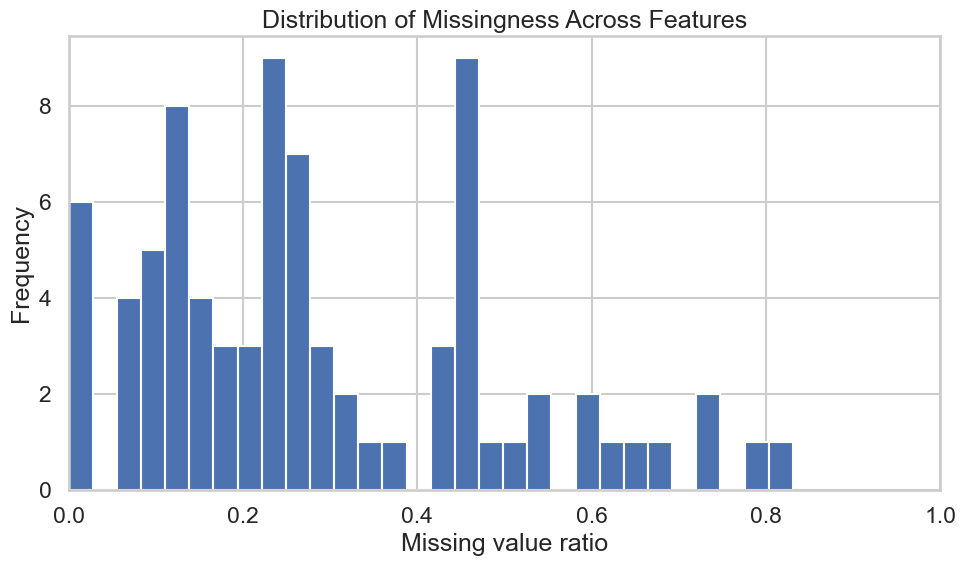

In [ ]:
missing_ratio = merged_dataset.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
missing_ratio.plot(kind="hist", bins=30)
plt.xlabel("Missing value ratio")
plt.xlim([0.0, 1.0])
plt.title("Distribution of Missingness Across Features")
plt.tight_layout()
plt.savefig(config.PROJECT_ROOT / 'reports/plots' / 'missing_values_histogram.png', bbox_inches='tight')
plt.show()

### 3.2.1 Missingness Matrix for Features over Time

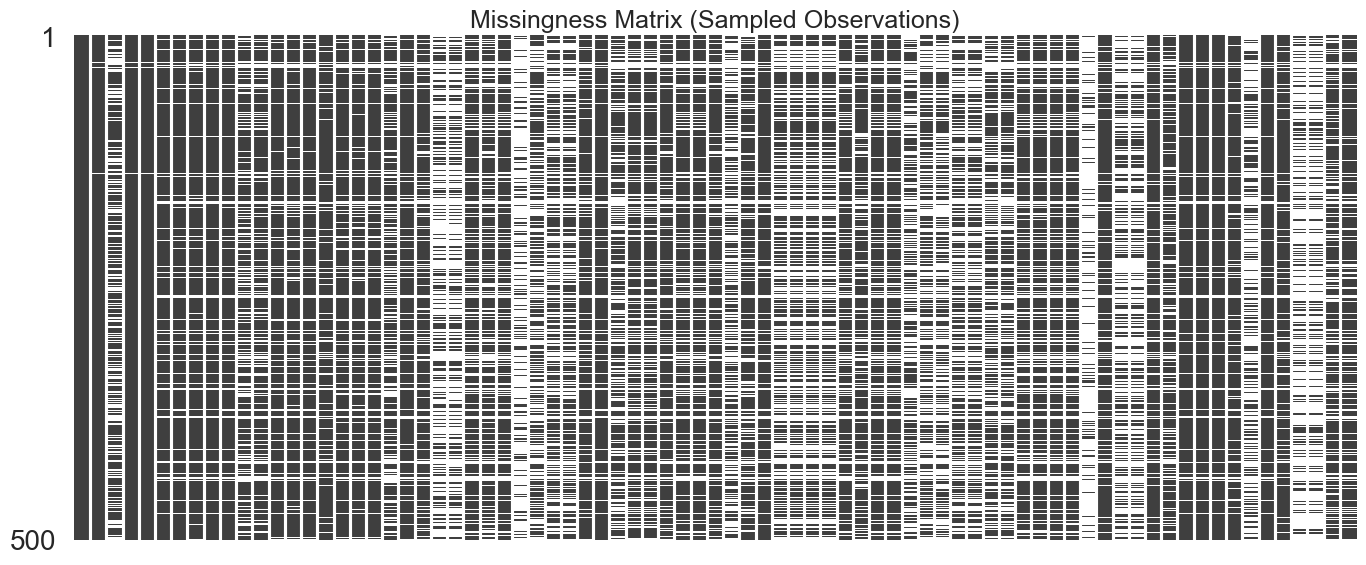

In [ ]:
msno_matrix(
    merged_dataset.sort_values(by=['YEAR']).drop(columns=config.info_columns).sample(min(len(worldbank_df), 500)),
    figsize=(14, 6),
    sparkline=False
)
plt.title("Missingness Matrix (Sampled Observations)")
plt.tight_layout()
plt.savefig(config.PROJECT_ROOT / 'reports/plots' / 'missingness_matrix.png', bbox_inches='tight')
plt.show()

### 3.2.1 Correlation of Missingness Between Features

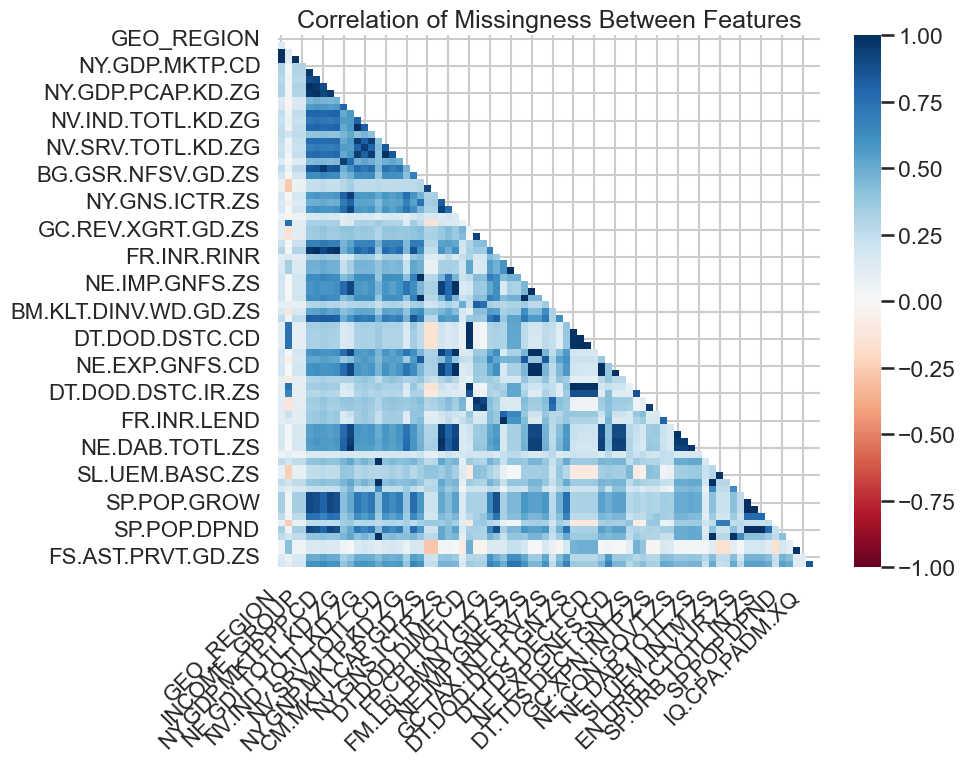

In [ ]:
msno_heatmap(merged_dataset, figsize=(10, 8), labels=False)
plt.title("Correlation of Missingness Between Features")
plt.tight_layout()
plt.savefig(config.PROJECT_ROOT / 'reports/plots' / 'missingness_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 3.3 Coverage by Country Analysis

In [28]:
coverage = merged_dataset.groupby("ISO3_COUNTRY_CODE") \
.apply(lambda x: x.notna().mean().mean()) \
.sort_values()

/var/folders/z6/32ll3t5d46q7xhp0hcl2wpww0000gn/T/ipykernel_64767/818459852.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = merged_dataset.groupby("ISO3_COUNTRY_CODE") \


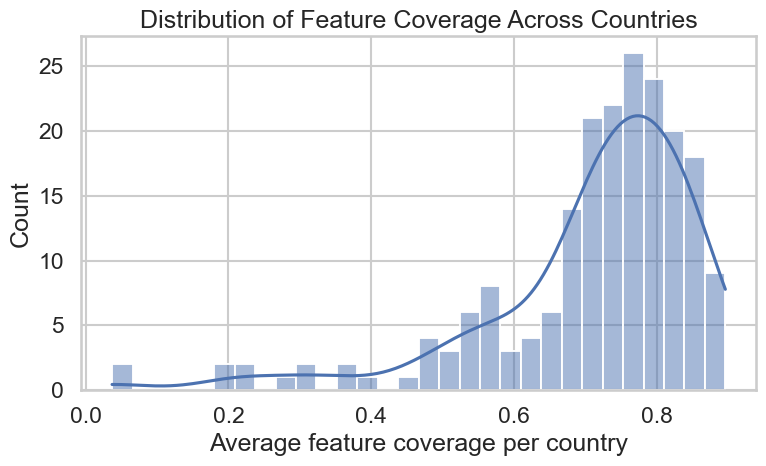

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(coverage, bins=30, kde=True)
plt.xlabel("Average feature coverage per country")
plt.title("Distribution of Feature Coverage Across Countries")
plt.tight_layout()
plt.savefig(config.PROJECT_ROOT / 'reports/plots' / 'country_feature_coverage_distribution.png', bbox_inches='tight')
plt.show()

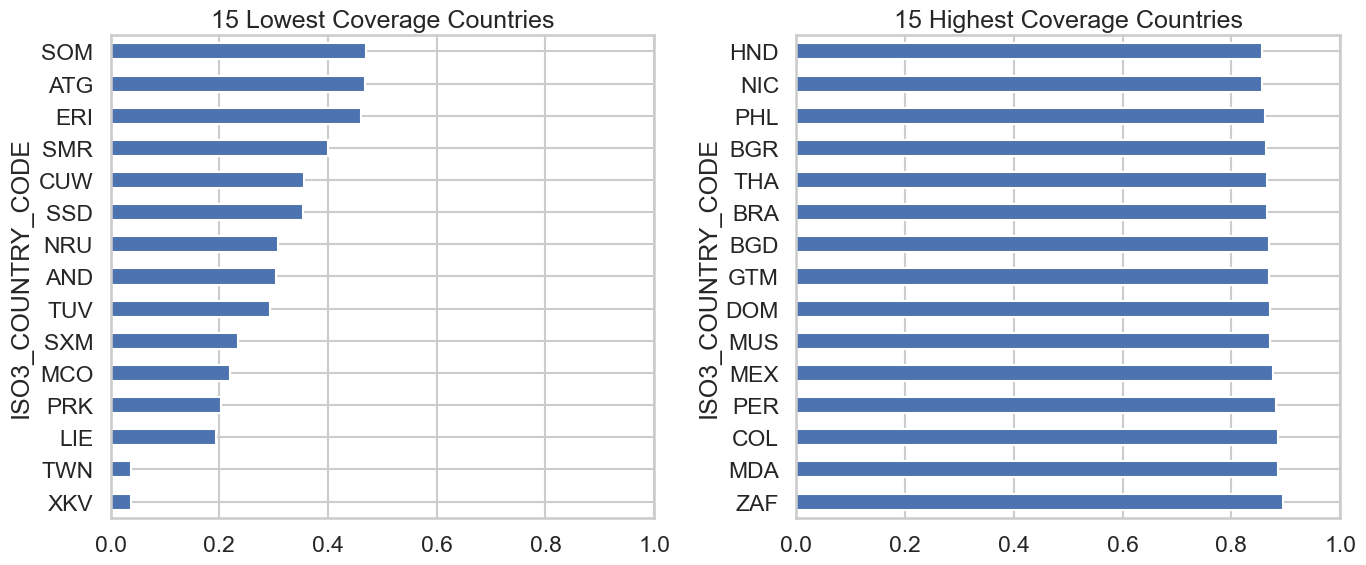

In [30]:
N = 15

worst = coverage.nsmallest(N)
best = coverage.nlargest(N)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


worst.plot(kind="barh", ax=axes[0])
axes[0].set_title(f"{N} Lowest Coverage Countries")
axes[0].set_xlim([0.0, 1.0])

best.plot(kind="barh", ax=axes[1])
axes[1].set_title(f"{N} Highest Coverage Countries")
axes[1].set_xlim([0.0, 1.0])

plt.tight_layout()
plt.show()

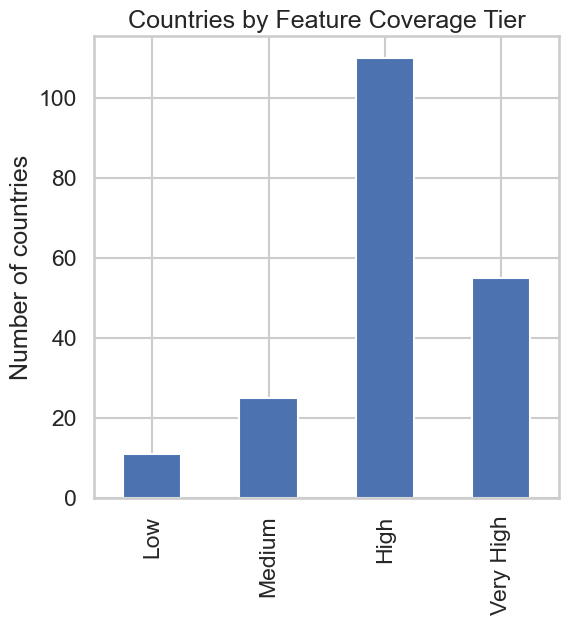

In [31]:
import pandas as pd
coverage_bins = pd.cut(
    coverage,
    bins=[0, 0.4, 0.6, 0.8, 1.0],
    labels=["Low", "Medium", "High", "Very High"]
)

coverage_summary = coverage_bins.value_counts().sort_index()

plt.figure(figsize=(6, 6))
coverage_summary.plot(kind="bar")
plt.ylabel("Number of countries")
plt.title("Countries by Feature Coverage Tier")
plt.show()